In [390]:
import pandas as pd
import numpy as np


df = pd.read_excel("ID_data_mass_18122012.xlsx", 
                   sheet_name="VU", 
                   skiprows=1, 
                   na_values=["не спускался", "-", "", " "],
                )

df = df.drop(index=0).rename(columns={"Unnamed: 0": "Number", "Unnamed: 1": "Date"})
df[df.columns[2:]] = df[df.columns[2:]].astype(np.float64)
df.Number = df.Number.astype(np.float64)
df.Date = pd.to_datetime(df.Date).astype(np.int64)
df

,Number,Date,Глубина манометра,Dшт,Руст,Рзаб,Pлин,Руст.1,Рзаб.1,Рлин,...,Рпл. Тек (Карноухов),Pсб,Pсб.1,Ro_g,Ro_c,Ro_w,Удельная плотность газа,G_total,КГФ,КГФ.1
1,804.0,1212624000000000,3576.3,7.94,249.6,370.1000,101.800000,249.0,359.6,101.800000,...,NaN,93.6,92.376018,0.806017,801.0,1000.0,0.669449,2.782623,311.9094,NaN
2,804.0,1212710400000000,3576.3,9.53,233.5,364.6000,101.300000,231.0,338.1,102.400000,...,NaN,92.9,91.685171,0.806017,801.0,1000.0,0.669449,3.697781,288.6003,NaN
3,804.0,1212796800000000,3576.3,11.11,213.4,357.1000,101.600000,211.0,314.8,100.600000,...,NaN,91.4,90.204787,0.806017,801.0,1000.0,0.669449,4.515073,248.7906,NaN
4,804.0,1212883200000000,3576.3,12.70,191.6,347.4000,98.400000,187.0,291.5,99.000000,...,NaN,89.2,88.033555,0.806017,801.0,1000.0,0.669449,5.217673,223.5591,NaN
5,804.0,1212969600000000,3576.3,14.29,171.9,337.7000,99.200000,169.0,270.3,99.500000,...,NaN,89.7,88.527017,0.806017,801.0,1000.0,0.669449,5.765092,215.1486,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,22505.0,1253664000000000,3678.0,12.70,182.2,271.5860,93.255111,179.0,258.6,92.702141,...,60.8,89.7,88.527017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
182,22505.0,1254009600000000,3678.0,14.29,157.0,249.0760,96.472143,153.0,233.5,100.060417,...,60.8,87.3,86.158401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
183,22505.0,1270771200000000,3679.5,7.94,211.9,289.3877,91.131226,208.0,289.6,91.304642,...,61.3,88.2,87.046632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
184,22505.0,1271203200000000,3679.5,9.53,204.0,282.8709,91.173008,201.0,275.3,91.616821,...,61.3,88.5,87.342709,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [391]:
def merge(x: pd.Series) -> np.float64:
    return x["КГФ"] if not np.isnan(x["КГФ"]) else x["КГФ.1"] * 1000


df["KGF"] = df.apply(merge, axis=1)
df = df.dropna(subset=["G_total", "KGF"], how="all").drop(labels=["КГФ", "КГФ.1"], axis=1)
df

,Number,Date,Глубина манометра,Dшт,Руст,Рзаб,Pлин,Руст.1,Рзаб.1,Рлин,...,Рпл. Тек (Расчет по КВД),Рпл. Тек (Карноухов),Pсб,Pсб.1,Ro_g,Ro_c,Ro_w,Удельная плотность газа,G_total,KGF
1,804.0,1212624000000000,3576.3,7.94,249.600000,370.1,101.800000,249.0,359.6,101.800,...,56.5,NaN,93.6,92.376018,0.806017,801.0,1000.0,0.669449,2.782623,311.9094
2,804.0,1212710400000000,3576.3,9.53,233.500000,364.6,101.300000,231.0,338.1,102.400,...,56.5,NaN,92.9,91.685171,0.806017,801.0,1000.0,0.669449,3.697781,288.6003
3,804.0,1212796800000000,3576.3,11.11,213.400000,357.1,101.600000,211.0,314.8,100.600,...,56.5,NaN,91.4,90.204787,0.806017,801.0,1000.0,0.669449,4.515073,248.7906
4,804.0,1212883200000000,3576.3,12.70,191.600000,347.4,98.400000,187.0,291.5,99.000,...,56.5,NaN,89.2,88.033555,0.806017,801.0,1000.0,0.669449,5.217673,223.5591
5,804.0,1212969600000000,3576.3,14.29,171.900000,337.7,99.200000,169.0,270.3,99.500,...,56.5,NaN,89.7,88.527017,0.806017,801.0,1000.0,0.669449,5.765092,215.1486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,22503.0,1233100800000000,3284.0,12.70,215.000000,307.8,98.600000,215.0,308.1,97.200,...,40.5,41.6,94.4,93.165556,NaN,782.0,NaN,0.660000,NaN,153.0000
165,22503.0,1233446400000000,3284.0,14.29,198.000000,293.6,98.500000,197.0,293.9,98.400,...,40.5,41.6,94.0,92.770787,NaN,782.0,NaN,0.660000,NaN,147.0000
166,22503.0,1281916800000000,3288.6,7.94,231.229167,309.1,92.600000,230.0,307.1,92.700,...,NaN,NaN,89.9,88.724402,NaN,779.6,NaN,0.668000,NaN,182.0000
167,22503.0,1282262400000000,3288.6,11.11,217.201681,293.9,93.100000,215.0,293.9,93.300,...,NaN,NaN,90.8,89.612633,NaN,779.6,NaN,0.668000,NaN,145.0000


G_total 4.523561956057012
KGF 6.057923461622403


,Дебит кон нестабильный,Тзаб,Tлин,Ro_c,Дебит гааз,Ro_w,Рлин,Ro_g,Руст.1,Рзаб,...,Удельная плотность газа,Тна шлейфе,Date,Дебит смеси,Дебит ст. конд.,Рзаб.1,Глубина манометра,Дебит газа,Рпл. Тек (Карноухов),Number
G_total,0.698658,0.754594,0.700986,0.956466,0.694048,-inf,0.704219,1.778941,0.744648,0.701609,...,0.935828,0.778999,0.700986,0.69854,0.694048,0.699199,0.933176,0.691765,1.114871,1.264612
KGF,0.925674,0.92993,0.925426,0.899212,0.926164,-inf,0.925082,2.469157,0.92396,0.932919,...,0.889404,1.03212,0.925426,0.935481,0.926164,0.933039,0.923619,0.926407,1.222359,0.861539


<Axes: >

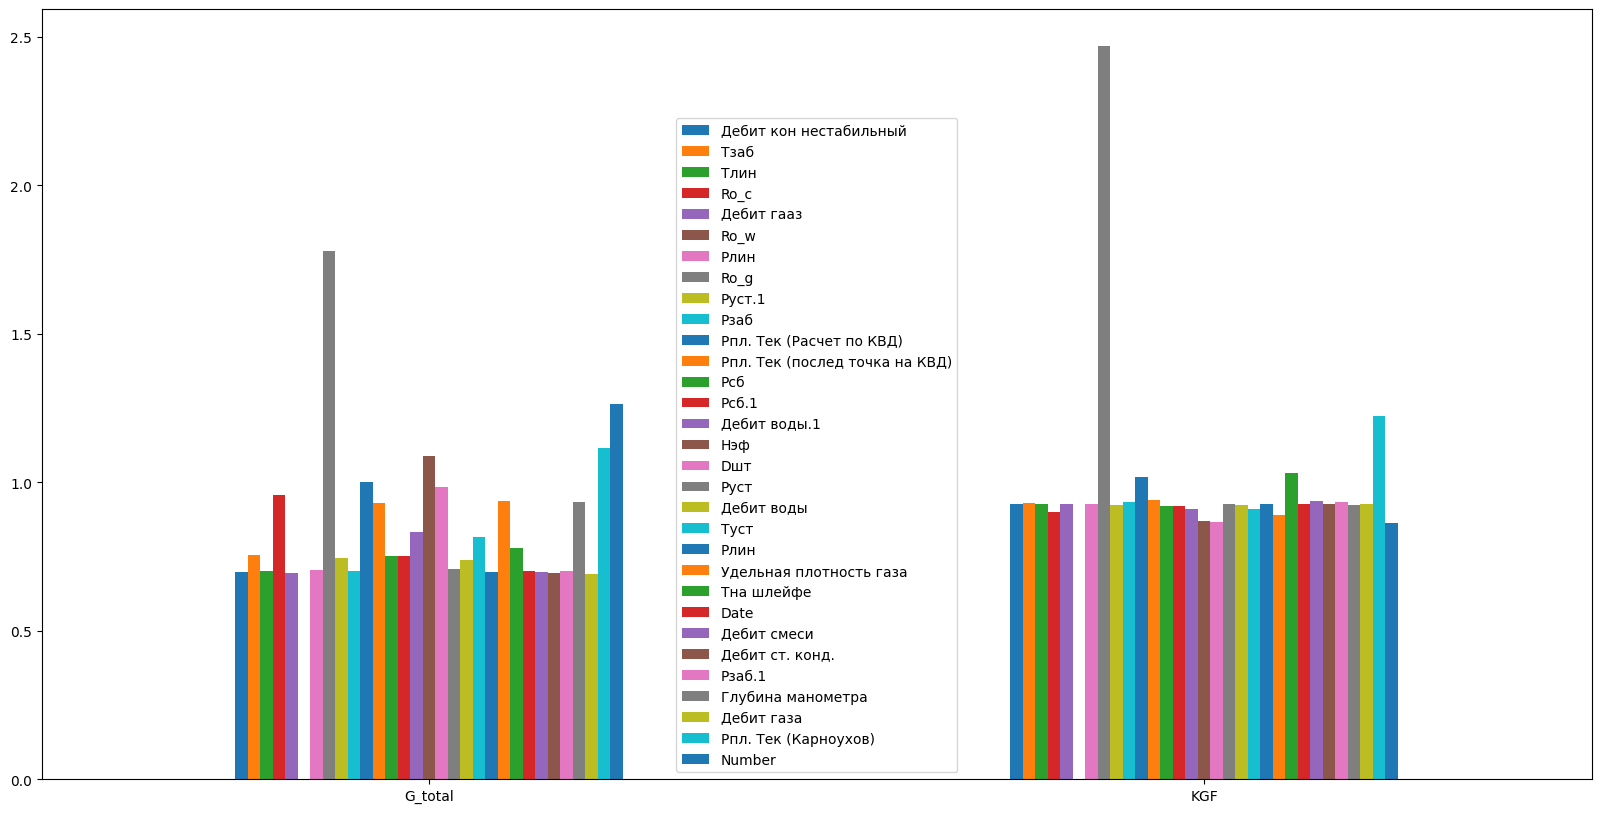

In [392]:
import numpy as np


mc = ["G_total", "KGF"]


def entropy(column: pd.Series) -> float:
    vc = column.value_counts(normalize=True, sort=False)
    return -(vc * np.log2(vc)).sum()

def information_gain(df: pd.DataFrame, mc_columns: list[str]) -> pd.DataFrame:
    result_columns = set(df.columns) - set(mc_columns)
    ig = pd.DataFrame(index=mc_columns, columns=list(result_columns))

    for mc_col in mc_columns:
        mc_entropy = entropy(df[mc_col])
        print(mc_col, mc_entropy)

        for col in result_columns:
            column = df[col]
            column_entropy = 0

            for value in column.unique():
                subset = df[column == value]
                subset_entropy = entropy(subset[mc_col])
                column_entropy += len(subset) / len(df) * subset_entropy

            ig.loc[mc_col, col] = mc_entropy - column_entropy

    return ig

def split_information(df: pd.DataFrame, mc_columns: list[str]):
    result_columns = set(df.columns) - set(mc_columns)
    si = pd.DataFrame(index=mc_columns, columns=list(result_columns))

    for col in result_columns:
        column = df[col]
        p = column.value_counts(normalize=True, sort=False)

        si.loc[:, col] = -(p * np.log2(p)).sum()

    return si


ig = information_gain(df, mc)
si = split_information(df, mc)
gain_ratio = ig / si

display(gain_ratio)
gain_ratio.plot.bar(figsize=(20, 10), rot=0)

,Number,Date,Глубина манометра,Dшт,Руст,Рзаб,Pлин,Руст.1,Рзаб.1,Рлин,...,Рпл. Тек (Расчет по КВД),Рпл. Тек (Карноухов),Pсб,Pсб.1,Ro_g,Ro_c,Ro_w,Удельная плотность газа,G_total,KGF
Number,1.000000,0.057660,0.324749,0.023674,0.067203,0.048034,0.222517,0.072008,0.041351,0.190150,...,0.247937,0.075658,0.121319,0.121319,0.020156,0.109634,NaN,0.013534,0.450412,0.081185
Date,0.057660,1.000000,0.020387,0.073387,0.118697,0.216952,0.067090,0.114924,0.230752,0.058995,...,0.174363,0.236953,0.698502,0.698502,0.614129,0.060309,NaN,0.250135,0.032874,0.328005
Глубина манометра,0.324749,0.020387,1.000000,0.133290,0.140302,0.290235,0.105731,0.132396,0.273486,0.090530,...,0.434805,0.631185,0.137804,0.137804,0.039118,0.237323,NaN,0.125062,0.419692,0.243306
Dшт,0.023674,0.073387,0.133290,1.000000,0.386698,0.176419,0.002905,0.389556,0.184689,0.108719,...,0.048616,0.123461,0.027716,0.027716,0.037575,0.093584,NaN,0.194179,0.735355,0.231636
Руст,0.067203,0.118697,0.140302,0.386698,1.000000,0.921603,0.296006,0.999288,0.941969,0.136337,...,0.130654,0.185203,0.174191,0.174191,0.583266,0.109322,NaN,0.380945,0.115329,0.494718
Рзаб,0.048034,0.216952,0.290235,0.176419,0.921603,1.000000,0.337914,0.917729,0.977898,0.149114,...,0.232267,0.273861,0.162901,0.162901,0.690170,0.025435,NaN,0.510577,0.282975,0.548383
Pлин,0.222517,0.067090,0.105731,0.002905,0.296006,0.337914,1.000000,0.302257,0.319696,0.583154,...,0.001505,0.018064,0.176807,0.176807,0.698405,0.056802,NaN,0.316899,0.276614,0.141389
Руст.1,0.072008,0.114924,0.132396,0.389556,0.999288,0.917729,0.302257,1.000000,0.940832,0.143812,...,0.118648,0.172570,0.174389,0.174389,0.606007,0.113124,NaN,0.383703,0.125809,0.481088
Рзаб.1,0.041351,0.230752,0.273486,0.184689,0.941969,0.977898,0.319696,0.940832,1.000000,0.136170,...,0.192804,0.296740,0.107786,0.107786,0.631656,0.047017,NaN,0.496102,0.311310,0.525020
Рлин,0.190150,0.058995,0.090530,0.108719,0.136337,0.149114,0.583154,0.143812,0.136170,1.000000,...,0.086255,0.036331,0.081058,0.081058,0.787366,0.049219,NaN,0.194180,0.312419,0.167872


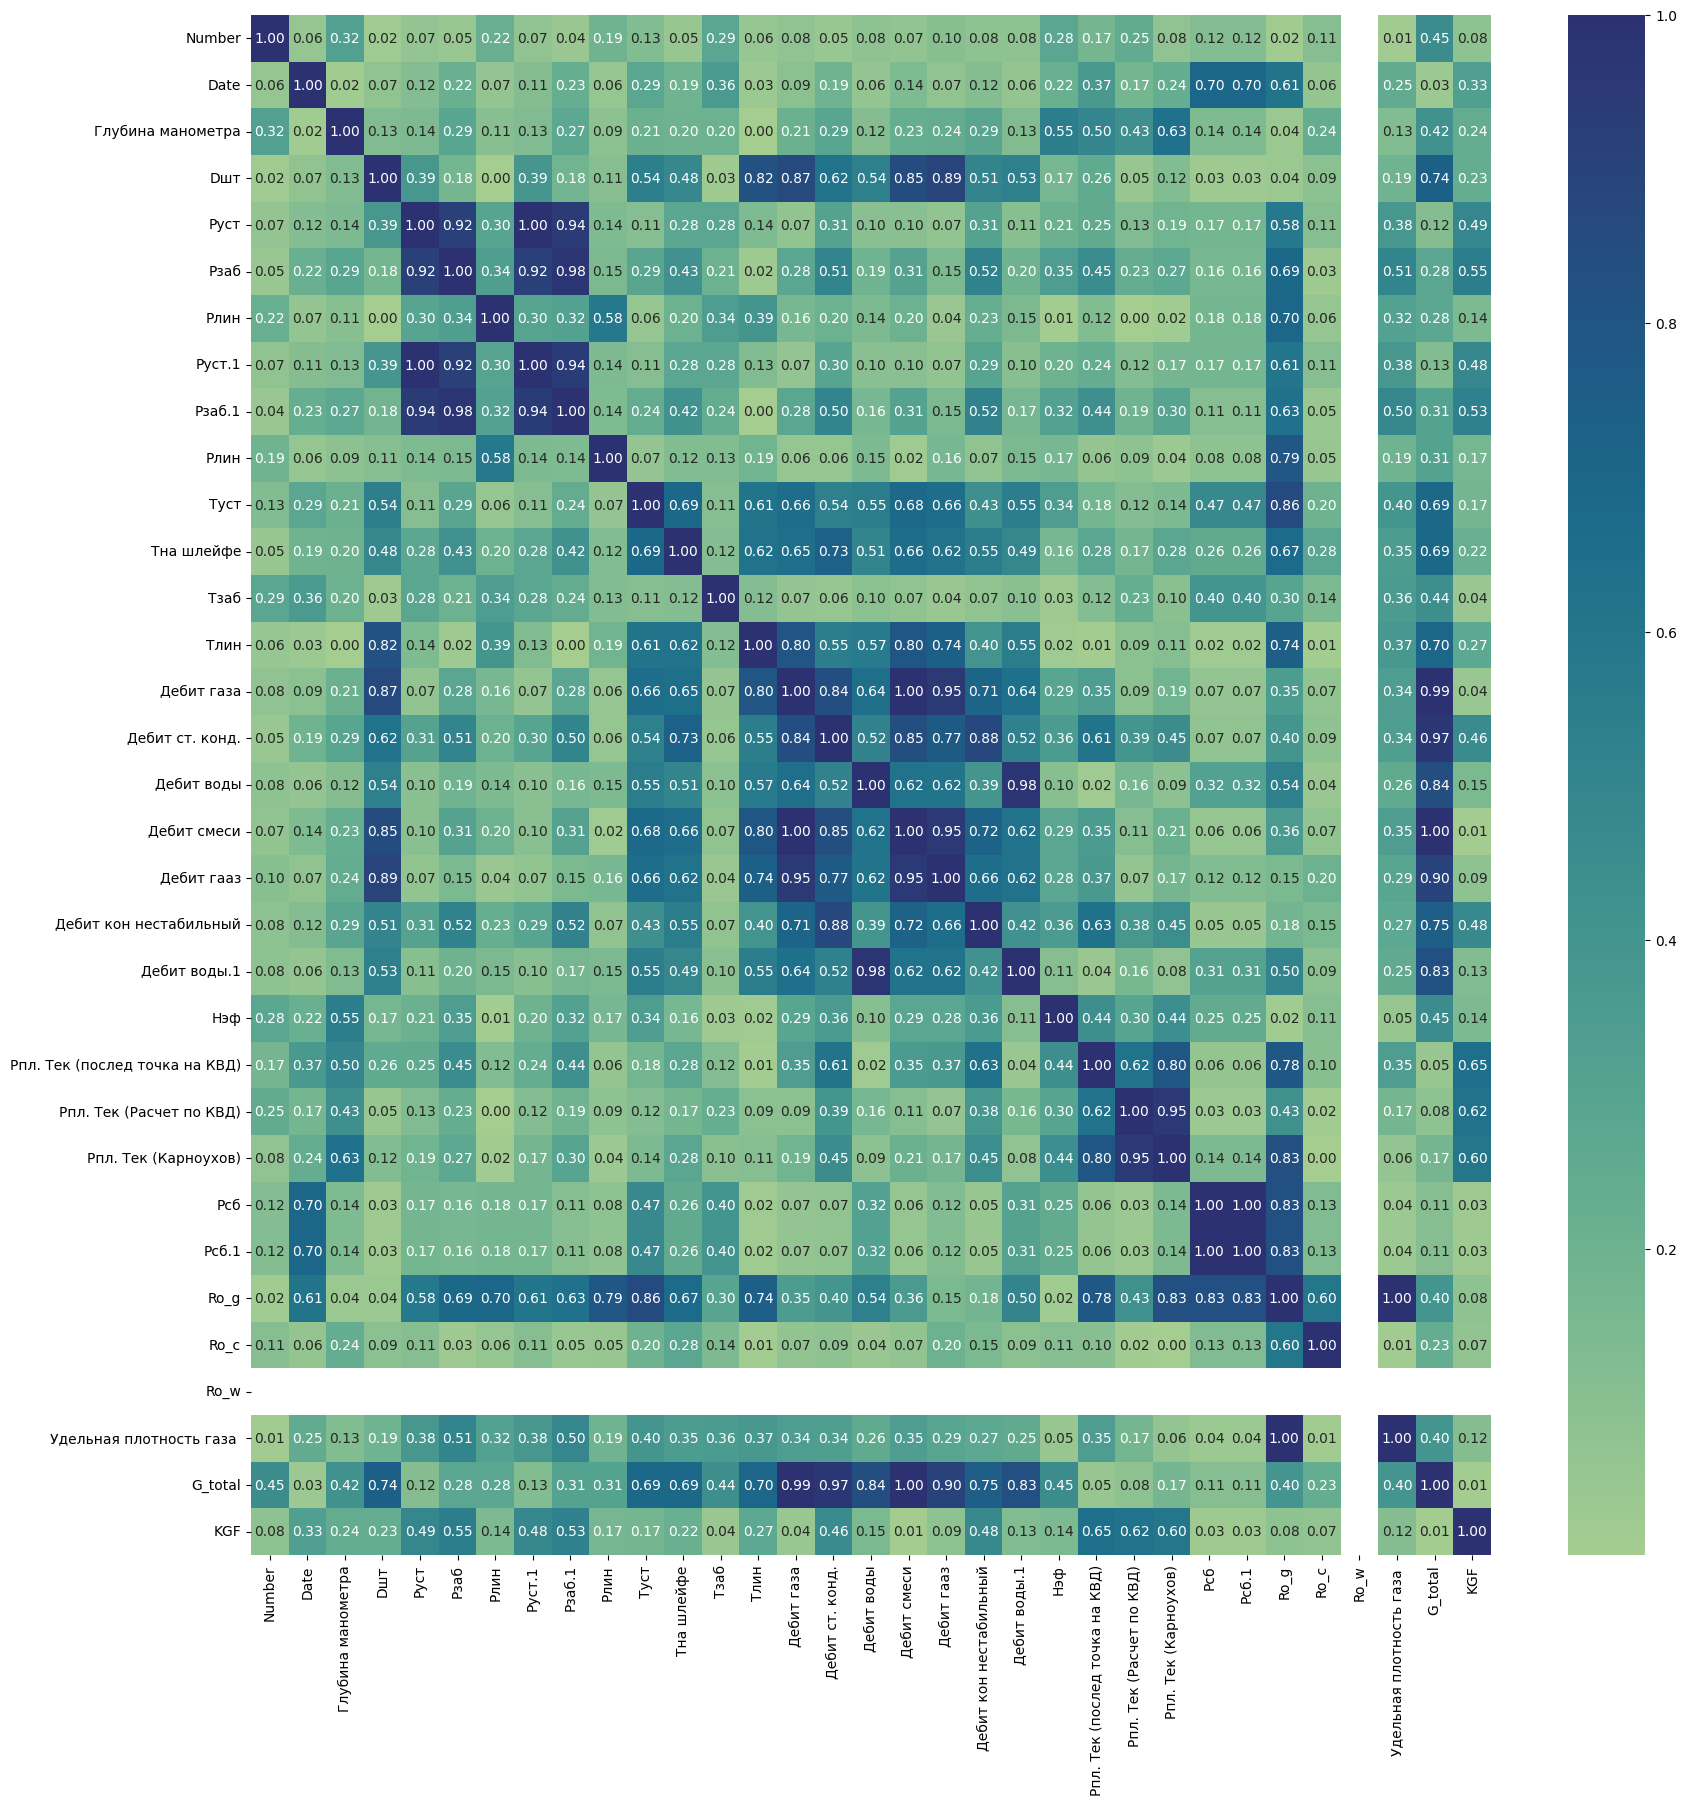

In [393]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.corr().abs()
display(corr)

plt.figure(figsize=(20, 20))
sns.heatmap(corr, cmap="crest", annot=True, fmt=".2f")
plt.show()